<a href="https://colab.research.google.com/github/zelal-Eizaldeen/deeplearning_course/blob/main/LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLMOps Practices

 There are different LLMOps practices, tooling, and infrastructure to see how different components help us overcome the challenges of LLMs like large sizes and latency.

Compression: where we will talk about shrinking, trimming, and approximating to get models as small as we can.

Compressing models to as small as we can make them will improve deployment time, reduce latency, scale down the number of expensive GPUs needed, and, ultimately, save money.

There are several methods to compress the size of the model:
1. Quantization
2. Pruning
3. Knowledge distillation
4. Low-rank approximation

# Low-rank approximation

Low-rank approximation, also known as low-rank factorization, low-rank decomposition, or matrix factorization that uses linear algebra math tricks to simplify large matrices or tensors to find a lower-dimensional representation. There are several techniques to do this. Singular value decomposition (SVD), Tucker decomposition (TD), and canonical polyadic decomposition (CPD) are the most common ones you run into.

we show the general idea behind the SVD method. Essentially, we are going to take a very large matrix, A, and break it up into three smaller matrices, U, S, and V. While U and V are there to ensure we keep the same dimensions and relative strengths of the original matrix, S allows us to apply a direction and bias. The smaller S is, the more we end up compressing and reducing the total number of parameters, but the less accurate the approximation becomes.

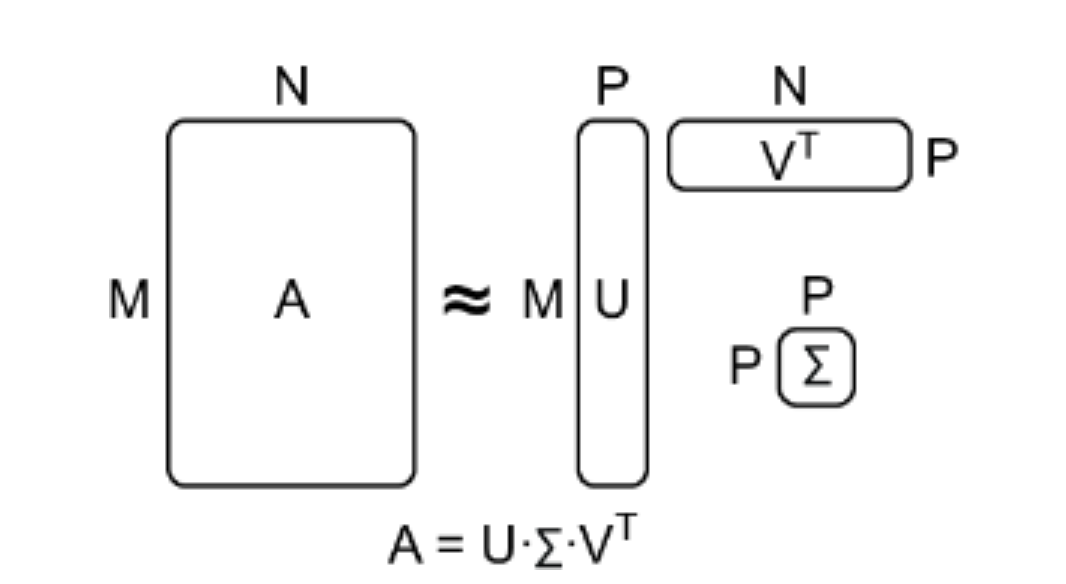

Example of SVD, a low-rank approximation. A is a large matrix with dimensions N and M. We can approximate it with three smaller matrices: U with dimensions M and P, S a square matrix with dimension P, and V with dimensions N and P (here we show the transpose). Usually, both P<<M and P<<N are true.

In the next listing, we show a simple example of SVD at work compressing a … matrix. For this, we only need the basic libraries SciPy and NumPy,

Where:

U contains left singular vectors

S contains singular values

V^T contains right singular vectors

 for k = 1

So instead of computing all singular vectors, SciPy returns only the largest singular value and its corresponding singular vectors.

This is known as the best rank-1 approximation of the matrix.

we now only need 9 parameters versus the original 16, shrinking the memory footprint almost by half.



In [1]:
import scipy
import numpy as np
matrix = np.array([   #define the matrix
    [ 1., 2., 3., 4.],
    [ 5., 6., 7., 8.],
    [ 9., 10., 11., 12.],
    [13., 14., 15., 16.]
])
u, s, vt = scipy.sparse.linalg.svds(matrix, k=1)
print(u,s,vt)
# [[-0.13472211]
# [-0.34075767]
# [-0.5467932 ]

[[-0.13472212]
 [-0.3407577 ]
 [-0.54679327]
 [-0.75282884]] [38.62265683] [[-0.4284124  -0.47437252 -0.52033264 -0.56629275]]


u → left singular vector

Shape: (4, 1)
This is the direction in the row space that dominates the matrix.

2. s → singular value

Shape: (1,)
This is the magnitude of the strongest “pattern” in the matrix.

3. vt → right singular vector (transposed)

Shape: (1, 4)
This shows the dominant direction in the column space.

output explanation:

u =
[[-0.13472212]
 [-0.3407577 ]
 [-0.54679327]
 [-0.75282884]]

s = [38.62265683]

vt =
[[-0.4284124  -0.47437252 -0.52033264 -0.56629275

A singular value is like “how much energy or variance” the matrix has along a particular direction.

Large s ≈ strong dominant structure in the matrix

Lastly, we multiply the matrices back together to get an approximation of the original matrix. In this case, the approximation isn’t all that great, but we can still see that the general order and magnitudes match the original matrix:

In [2]:
svd_matrix = u*s*vt
print(svd_matrix)

[[ 2.22916951  2.46831501  2.70746051  2.94660601]
 [ 5.63832164  6.24320129  6.84808093  7.45296058]
 [ 9.04747378 10.01808757 10.98870135 11.95931514]
 [12.45662591 13.79297384 15.12932177 16.4656697 ]]


#LoRA

Unfortunately, we are not aware of anyone actually using this to compress models in production, most likely due to the poor accuracy of the approximation.

What they are using it for—and this is important—is adaptation and finetuning, which is where low-rank adaptation (LoRA) comes in.

Adaptation is the process of finetuning a generic or base model to do a specific task.

LoRA applies SVD low-rank approximation to the attention weights or, rather, to inject update matrices that run parallel to the attention weights, allowing us to finetune a much smaller model.

LoRA has become very popular because it makes it a breeze to take an LLM, shrink the trainable layers to a tiny fraction of the original model, and then allow anyone to train it on commodity hardware.

You can get started with LoRA using the PEFT library from Hugging Face,

[PEFT](https://https://huggingface.co/docs/peft.)